In [3]:
!pip install numpy pandas opencv-python matplotlib pillow scikit-image scipy torch torchvision grad-cam gdown

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 53.8 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=7fb14f4547cad1c27e7e181aaac742d415af5601ad43bdf6242962e36d7eb5c7
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [4]:
import os, sys, json, zipfile, re, warnings, io
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, cv2, matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from collections import defaultdict
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score

import torch, torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

try:
    from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    os.system('pip install -q pytorch-grad-cam')
    from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image

try:
    import gdown
except ImportError:
    os.system('pip install -q gdown')
    import gdown

from skimage import measure
from scipy.spatial import ConvexHull

torch.manual_seed(42); np.random.seed(42)
NUM_GPUS = torch.cuda.device_count()
DEVICE_0 = torch.device("cuda:0" if NUM_GPUS > 0 else "cpu")
DEVICE_1 = torch.device("cuda:1" if NUM_GPUS > 1 else ("cuda:0" if NUM_GPUS > 0 else "cpu"))
print(f"GPUs available: {NUM_GPUS} | PyTorch: {torch.__version__}")
print(f"Model 1 will use {DEVICE_0}")
print(f"Model 2 will use {DEVICE_1}")


GPUs available: 2 | PyTorch: 2.10.0+cu128
Model 1 will use cuda:0
Model 2 will use cuda:1


In [10]:
CONFIG = {
    'drive_ids': {
        'chexlocalize': '1RNLBI330gFX3cYjN64S3HUsHiDuVQKXL',
        'images': '1dOvsnktP_rOoKiD0lleNdYJU-UcvlM50',
        'csv_splits': '1cym7lVa3_ZXZj_-G9gYFNp6AhdogXEIH',
        'imagenet_model': '1cV-Ogjeg15wiEeX7B3mWYoKj5n9hiOm0',
        'radimagenet_model': '1i3JBVCow67Ar4i0qcuTBBW6313zV0O5g',
    },
    'local_weights': {
        'imagenet': './spec_best_model.pth',
        'radimagenet': './cooling_best_model.pth',
    },
    'paths': {
        'base_dir': './xai_data',
        'chexlocalize_zip': './xai_data/chexlocalize.zip',
        'images_zip': './xai_data/chexpert_full.zip',
        'csv_zip': './xai_data/csv_splits.zip',
        'models_dir': './xai_models',
    },
    'classes': [
        'Airspace Opacity', 'Pleural Effusion', 'Edema',
        'Atelectasis', 'Cardiomegaly', 'Enlarged Cardiomediastinum'
    ],
    'preprocessing': {
        'img_size': (224, 224),
        'clahe_clip': 2.0,
        'norm_mean': [0.485, 0.456, 0.406],
        'norm_std': [0.229, 0.224, 0.225],
    },
}
NUM_CLASSES = len(CONFIG['classes'])
print(f"Classes ({NUM_CLASSES}): {CONFIG['classes']}")


Classes (6): ['Airspace Opacity', 'Pleural Effusion', 'Edema', 'Atelectasis', 'Cardiomegaly', 'Enlarged Cardiomediastinum']


In [6]:
class ZipImageReader:
    def __init__(self, zip_path):
        self.zip_path = zip_path
        self.zip_file = None

    def get_image(self, internal_path):
        if self.zip_file is None:
            self.zip_file = zipfile.ZipFile(self.zip_path, 'r')
        
        try:
            with self.zip_file.open(internal_path) as f:
                img_data = f.read()
                return Image.open(io.BytesIO(img_data)).convert('RGB')
        except Exception as e:
            return None

class ApplyCLAHE:
    def __init__(self, clip_limit=2.0):
        self.clip_limit = clip_limit

    def __call__(self, img):
        img_np = np.array(img)
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=(8, 8))
        if len(img_np.shape) == 3:
            lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            cl = clahe.apply(l)
            final_img = cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2RGB)
        else:
            final_img = clahe.apply(img_np)
        return Image.fromarray(final_img)

class CheXpertEvaluationDataset(Dataset):
    def __init__(self, csv_path, zip_reader, classes, transform=None):
        self.df = pd.read_csv(csv_path)
        self.zip_reader = zip_reader
        self.classes = classes
        self.transform = transform
        
        # Cleanup
        self.df = self.df.dropna(subset=['absolute_path'])
        self.df = self.df.loc[:, ~self.df.columns.str.endswith('.1')]
        self.df['clean_path'] = self.df['absolute_path'].apply(
            lambda x: x[x.find('CheXpert-v1.0-small'):] if 'CheXpert-v1.0-small' in str(x) else str(x).lstrip('/')
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        rel_path = row['clean_path']
        image = self.zip_reader.get_image(rel_path)
        
        if image is None:
            image = Image.new('RGB', CONFIG['preprocessing']['img_size']) # Return empty if fails

        if self.transform:
            image = self.transform(image)
            
        labels = row[self.classes].values.astype(np.float32)
        # Handle -1 (uncertain) if present, though Model_Test shouldn't have them
        labels[labels == -1.0] = np.nan
        labels = torch.tensor(labels, dtype=torch.float32)
        
        return image, labels


In [11]:
def download_if_missing(drive_id, output_path, name="file"):
    if not drive_id: return False
    if os.path.exists(output_path):
        print(f"  {name} already exists: {output_path}")
        return True
    print(f"  Downloading {name}...")
    gdown.download(f'https://drive.google.com/uc?id={drive_id}', output_path, quiet=False)
    return os.path.exists(output_path)

def extract_zip(zip_path, extract_to):
    if os.path.exists(zip_path):
        print(f"  Extracting {os.path.basename(zip_path)}...")
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(extract_to)

os.makedirs(CONFIG['paths']['base_dir'], exist_ok=True)
os.makedirs(CONFIG['paths']['models_dir'], exist_ok=True)

ids = CONFIG['drive_ids']
paths = CONFIG['paths']

print("=== Downloading Data ===")
download_if_missing(ids['chexlocalize'], paths['chexlocalize_zip'], 'CheXlocalize')
download_if_missing(ids['images'], paths['images_zip'], 'CheXpert Images')
download_if_missing(ids['csv_splits'], paths['csv_zip'], 'CSV Splits')

for zp in [paths['chexlocalize_zip'], paths['csv_zip']]:
    if os.path.exists(zp):
        extract_zip(zp, paths['base_dir'])

print("\n=== Downloading Model Weights ===")
for mkey, did_key, local_key in [('imagenet', 'imagenet_model', 'imagenet'),
                                   ('radimagenet', 'radimagenet_model', 'radimagenet')]:
    did = ids.get(did_key, '')
    local = CONFIG['local_weights'][local_key]
    dst = os.path.join(paths['models_dir'], f'{mkey}_best.pth')
    if did:
        download_if_missing(did, dst, f'{mkey} model')
    elif os.path.exists(local):
        import shutil
        if not os.path.exists(dst):
            shutil.copy2(local, dst)
        print(f"  {mkey}: using local weights {local} -> {dst}")
    else:
        print(f"  WARNING: No weights found for {mkey}!")

IMG_ZIP_PATH = paths['images_zip']
print(f"\nSetup complete! ZipImageReader will use {IMG_ZIP_PATH} from memory.")


=== Downloading Data ===
  CheXlocalize already exists: ./xai_data/chexlocalize.zip


Downloading...
From (original): https://drive.google.com/uc?id=1dOvsnktP_rOoKiD0lleNdYJU-UcvlM50
From (redirected): https://drive.google.com/uc?id=1dOvsnktP_rOoKiD0lleNdYJU-UcvlM50&confirm=t&uuid=2382712e-759d-477f-978a-6b8ffbff4796
To: /kaggle/working/xai_data/chexpert_full.zip
100%|██████████| 11.5G/11.5G [02:01<00:00, 95.0MB/s]


Downloading...
From: https://drive.google.com/uc?id=1cym7lVa3_ZXZj_-G9gYFNp6AhdogXEIH
To: /kaggle/working/xai_data/csv_splits.zip
100%|██████████| 3.53M/3.53M [00:00<00:00, 233MB/s]


  Extracting chexlocalize.zip...
  Extracting csv_splits.zip...

=== Downloading Model Weights ===


Downloading...
From (original): https://drive.google.com/uc?id=1cV-Ogjeg15wiEeX7B3mWYoKj5n9hiOm0
From (redirected): https://drive.google.com/uc?id=1cV-Ogjeg15wiEeX7B3mWYoKj5n9hiOm0&confirm=t&uuid=604e5a99-f4d0-4003-966c-39ec00366dba
To: /kaggle/working/xai_models/imagenet_best.pth
100%|██████████| 84.5M/84.5M [00:00<00:00, 138MB/s] 


Downloading...
From (original): https://drive.google.com/uc?id=1i3JBVCow67Ar4i0qcuTBBW6313zV0O5g
From (redirected): https://drive.google.com/uc?id=1i3JBVCow67Ar4i0qcuTBBW6313zV0O5g&confirm=t&uuid=c12900ae-6fa7-4266-8e99-8c44abd3e542
To: /kaggle/working/xai_models/radimagenet_best.pth
100%|██████████| 84.4M/84.4M [00:00<00:00, 163MB/s] 


Setup complete! ZipImageReader will use ./xai_data/chexpert_full.zip from memory.


In [12]:
def build_densenet121(num_classes):
    model = models.densenet121(weights=None)
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    return model

def load_model_weights(model, weights_path, device):
    if not os.path.exists(weights_path):
        print(f"WARNING: {weights_path} not found!")
        return model
    ckpt = torch.load(weights_path, map_location=device, weights_only=False)
    state = ckpt['model_state'] if isinstance(ckpt, dict) and 'model_state' in ckpt else (ckpt['state_dict'] if isinstance(ckpt, dict) and 'state_dict' in ckpt else ckpt)
    clean = {}
    for k, v in state.items():
        k2 = re.sub(r'^module\.', '', k)
        k2 = re.sub(r'norm\.(\d+)', r'norm\1', k2)
        k2 = re.sub(r'conv\.(\d+)', r'conv\1', k2)
        clean[k2] = v
    missing, unexpected = model.load_state_dict(clean, strict=False)
    backbone_missing = [k for k in missing if not k.startswith('classifier')]
    if backbone_missing:
        print(f"  WARNING: {len(backbone_missing)} backbone keys missing")
    print(f"  Loaded {len(clean)} keys, {len(missing)} missing, {len(unexpected)} unexpected")
    return model

models_dir = CONFIG['paths']['models_dir']

print(f"Loading ImageNet model on {DEVICE_0}...")
model_imagenet = build_densenet121(NUM_CLASSES)
model_imagenet = load_model_weights(model_imagenet, os.path.join(models_dir, 'imagenet_best.pth'), DEVICE_0)
model_imagenet.to(DEVICE_0).eval()

print(f"Loading RadImageNet model on {DEVICE_1}...")
model_radimagenet = build_densenet121(NUM_CLASSES)
model_radimagenet = load_model_weights(model_radimagenet, os.path.join(models_dir, 'radimagenet_best.pth'), DEVICE_1)
model_radimagenet.to(DEVICE_1).eval()

print("Models loaded successfully.")


Loading ImageNet model on cuda:0...
  Loaded 727 keys, 0 missing, 0 unexpected
Loading RadImageNet model on cuda:1...
  Loaded 727 keys, 0 missing, 0 unexpected
Models loaded successfully.


In [13]:
import glob

csv_base = CONFIG['paths']['base_dir']
test_csv_paths = glob.glob(os.path.join(csv_base, '**', 'Model_Test.csv'), recursive=True)
if not test_csv_paths:
    raise FileNotFoundError("Model_Test.csv not found in extracted files!")
test_csv = test_csv_paths[0]
print(f"Found test CSV at: {test_csv}")

pre = CONFIG['preprocessing']
transform = transforms.Compose([
    transforms.Resize(pre['img_size']),
    ApplyCLAHE(clip_limit=pre['clahe_clip']),
    transforms.ToTensor(),
    transforms.Normalize(mean=pre['norm_mean'], std=pre['norm_std'])
])

image_reader = ZipImageReader(IMG_ZIP_PATH)
test_dataset = CheXpertEvaluationDataset(test_csv, image_reader, CONFIG['classes'], transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print(f"Test dataset loaded with {len(test_dataset)} images.")


Found test CSV at: ./xai_data/FinalDataSet/Model_Test.csv
Test dataset loaded with 38328 images.


In [14]:
def evaluate_model(model, loader, device, classes):
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=f"Evaluating on {device}"):
            imgs = imgs.to(device)
            outputs = torch.sigmoid(model(imgs)).cpu().numpy()
            all_preds.append(outputs)
            all_targets.append(labels.numpy())
            
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    
    metrics = {}
    aucs = []
    maps = []
    
    for i, cls_name in enumerate(classes):
        valid_indices = ~np.isnan(all_targets[:, i])
        y_true = all_targets[valid_indices, i]
        y_pred = all_preds[valid_indices, i]
        
        if len(np.unique(y_true)) > 1:
            auc = roc_auc_score(y_true, y_pred)
            ap = average_precision_score(y_true, y_pred)
            metrics[cls_name] = {'AUROC': auc, 'mAP': ap}
            aucs.append(auc)
            maps.append(ap)
        else:
            metrics[cls_name] = {'AUROC': np.nan, 'mAP': np.nan}
            
    macro_auc = np.mean(aucs) if aucs else 0
    macro_map = np.mean(maps) if maps else 0
    
    return metrics, macro_auc, macro_map

print("Evaluating ImageNet model...")
img_metrics, img_macro_auc, img_macro_map = evaluate_model(model_imagenet, test_loader, DEVICE_0, CONFIG['classes'])

print("Evaluating RadImageNet model...")
rad_metrics, rad_macro_auc, rad_macro_map = evaluate_model(model_radimagenet, test_loader, DEVICE_1, CONFIG['classes'])

# Compile results
results_records = []
for cls in CONFIG['classes']:
    results_records.append({
        'disease': cls,
        'AUROC_ImageNet': img_metrics[cls]['AUROC'],
        'AUROC_RadImageNet': rad_metrics[cls]['AUROC'],
        'mAP_ImageNet': img_metrics[cls]['mAP'],
        'mAP_RadImageNet': rad_metrics[cls]['mAP'],
    })

class_df = pd.DataFrame(results_records)

print(f"\nTrue Macro AUROC - ImageNet: {img_macro_auc:.4f} | RadImageNet: {rad_macro_auc:.4f}")
print(f"True Macro mAP - ImageNet: {img_macro_map:.4f} | RadImageNet: {rad_macro_map:.4f}")

os.makedirs('./xai_results', exist_ok=True)
class_df.to_csv('./xai_results/classification_performance.csv', index=False)
print("Saved classification performance results to ./xai_results/classification_performance.csv")


Evaluating ImageNet model...


Evaluating on cuda:0: 100%|██████████| 1198/1198 [02:37<00:00,  7.63it/s]


Evaluating RadImageNet model...


Evaluating on cuda:1: 100%|██████████| 1198/1198 [02:07<00:00,  9.41it/s]


True Macro AUROC - ImageNet: 0.8625 | RadImageNet: 0.8402
True Macro mAP - ImageNet: 0.9472 | RadImageNet: 0.9330
Saved classification performance results to ./xai_results/classification_performance.csv


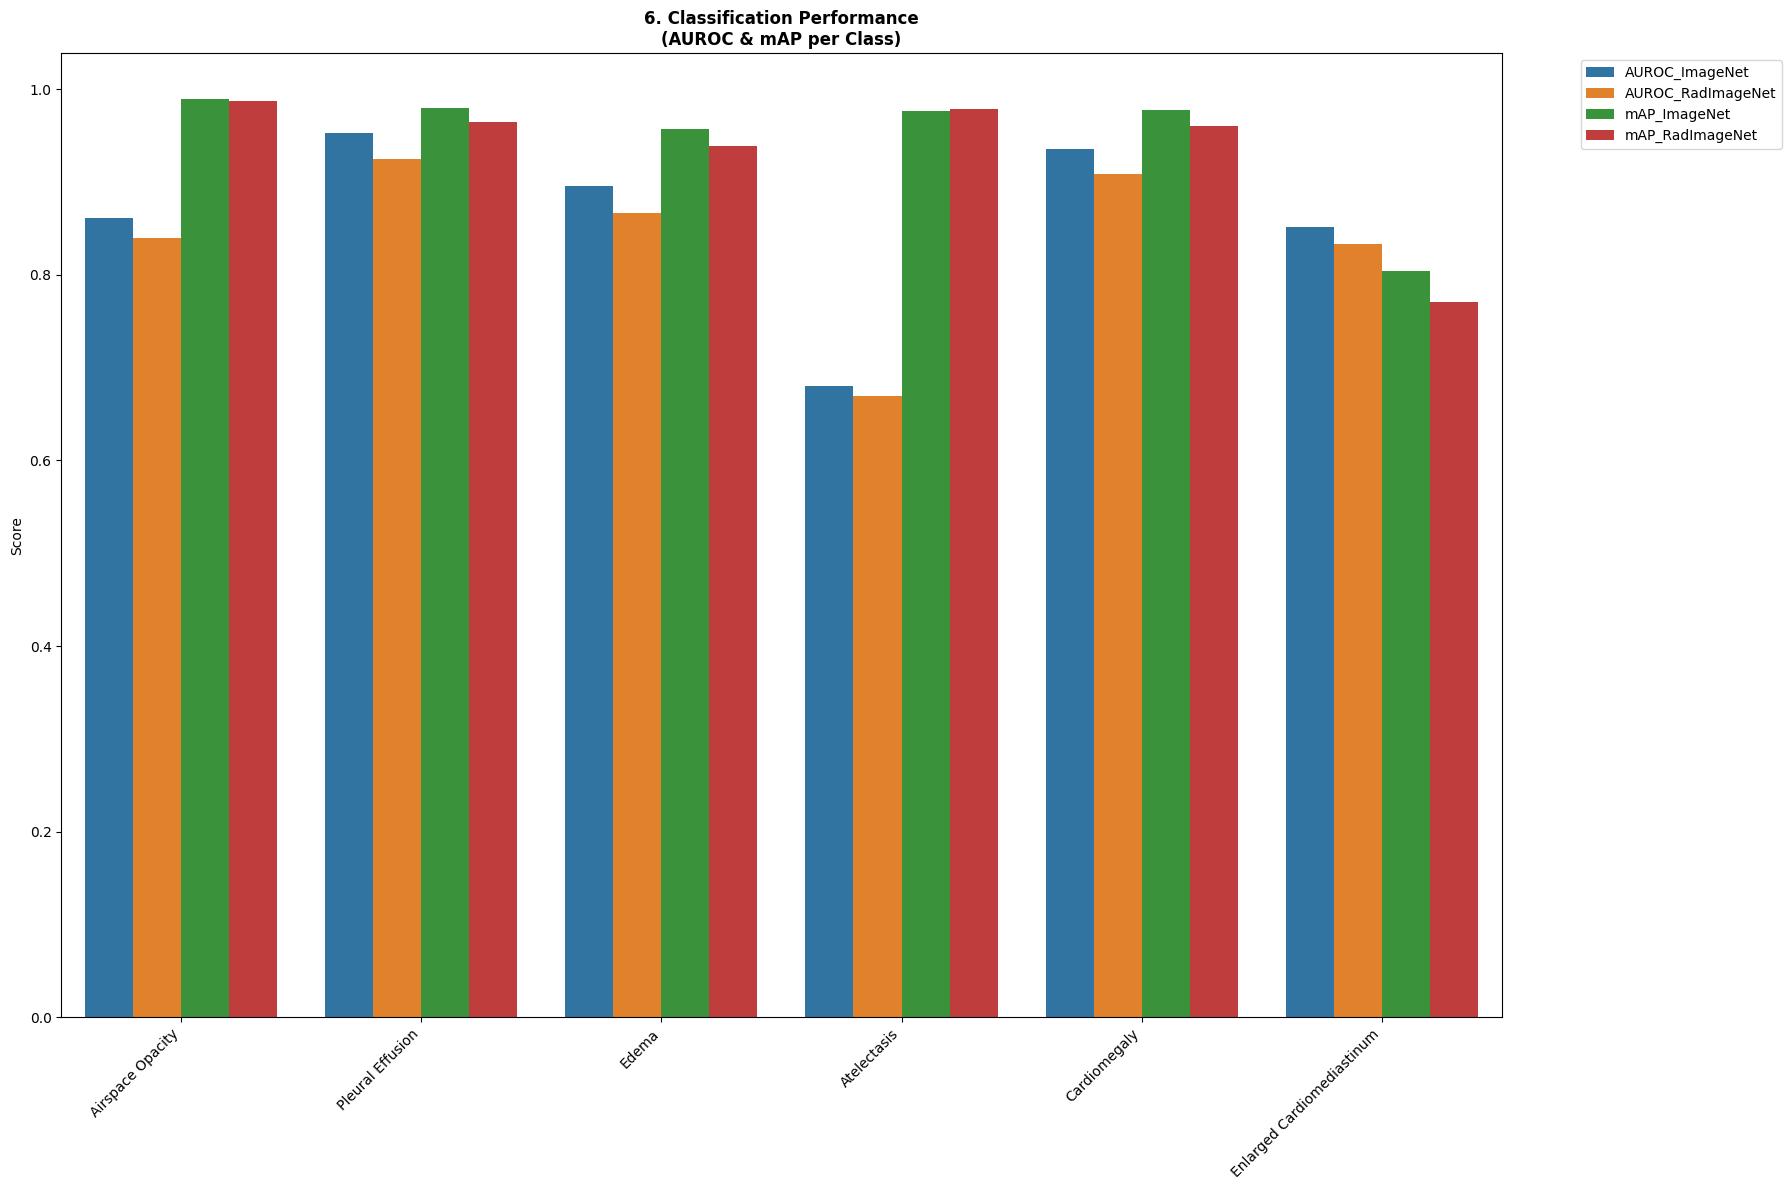

In [15]:
# 6. Classification Performance (AUROC & mAP)
plt.figure(figsize=(18, 12)) 
ax6 = plt.subplot(1, 1, 1) 
required_class_cols = {'disease', 'AUROC_ImageNet', 'AUROC_RadImageNet', 'mAP_ImageNet', 'mAP_RadImageNet'}

if required_class_cols.issubset(class_df.columns):
    class_melted = class_df.melt(id_vars='disease', value_vars=['AUROC_ImageNet', 'AUROC_RadImageNet', 'mAP_ImageNet', 'mAP_RadImageNet'], 
                                 var_name='Metric_Model', value_name='Score')
    sns.barplot(data=class_melted, x='disease', y='Score', hue='Metric_Model', ax=ax6)
    ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45, ha='right')
    ax6.set_title("6. Classification Performance\n(AUROC & mAP per Class)", fontweight='bold')
    ax6.set_xlabel("")
    ax6.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
else:
    ax6.axis('off')
    ax6.text(0.5, 0.5, 'Classification results are not available in the current files.', ha='center', va='center', fontsize=13)

plt.tight_layout()
os.makedirs('./xai_results', exist_ok=True)
plt.savefig('./xai_results/comprehensive_analysis_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
